In [1]:
    #Required Packages

    library(data.table)
    library(RColorBrewer)
    library("fdrtool")

    #Unconstrained Estimated Preference Function

    hat_h <- function(W, NN, x_points) {
      w <- W$Freq
      y_sum <- NN
      x_cum <- cumsum(w)
      y_cum <- cumsum(y_sum)
      x <- c(0, x_cum)
      y <- c(0, y_cum)
      gg <- gcmlcm(x, y)
      assign_slope <- function(x_point) {
        for (i in 1:(length(gg$x.knots) - 1)) {
          if (x_point > gg$x.knots[i] &&
              x_point <= gg$x.knots[i + 1]) {
            return(gg$slope.knots[i])
          }
        }
        return(NA)
      }
      slopes <- sapply(x_cum, assign_slope)
      X_vals <- W$X
      sapply(x_points, function(x_point) {
        idx_candidates <- which(X_vals <= x_point)
    if (length(idx_candidates) == 0) {
      return(NA)
    } else {
      idx <- max(idx_candidates)
      return(slopes[idx])
    }
      })
    }

    #Constrained Estimated Preference Function

    hat_h0 <- function(theta, W, NN, r0, x_points) {
      w <- W$Freq
      y_sum <- NN
      x_cum <- cumsum(w)
      y_cum <- cumsum(y_sum)
      X_vals <- W$X
      s0 <- max(which(X_vals <= r0))
      x_left <- c(0, x_cum[1:s0])
      y_left <- c(0, y_cum[1:s0])
      gcm_left <- gcmlcm(x_left, y_left)
      assign_left <- function(x_point) {
        for (i in 1:(length(gcm_left$x.knots)-1)) {
          if (x_point > gcm_left$x.knots[i] &&
              x_point <= gcm_left$x.knots[i+1]) {
            return(gcm_left$slope.knots[i])
          }
        }
        NA
      }
      slopes_left <- sapply(x_cum[1:s0], assign_left)
      slopes_left <- pmin(slopes_left, theta)
      if (s0 < length(x_cum)) {
        x_right <- x_cum[(s0+1):length(x_cum)] - x_cum[s0]
        y_right <- y_cum[(s0+1):length(y_cum)] - y_cum[s0]
        x_right <- c(0, x_right)
        y_right <- c(0, y_right)
        gcm_right <- gcmlcm(x_right, y_right)
        assign_right <- function(x_point) {
          for (i in 1:(length(gcm_right$x.knots)-1)) {
            if (x_point > gcm_right$x.knots[i] &&
                x_point <= gcm_right$x.knots[i+1]) {
              return(gcm_right$slope.knots[i])
            }
          }
          NA
        }
          
        slopes_right <- sapply(x_right[-1], assign_right)
        slopes_right <- pmax(slopes_right, theta)
       } else {
        slopes_right <- numeric(0)
      }
      slopes_all <- c(slopes_left, slopes_right)
      sapply(x_points, function(x_point) {
        idx_candidates <- which(X_vals <= x_point)
    if (length(idx_candidates) == 0) {
      return(NA)
    } else {
      idx <- max(idx_candidates)
      return(slopes_all[idx])
    }
      })
    }

    #Likelihood Function

    loglik_from_slopes <- function(slopes, W, NN) {
       w <- W$Freq
       y <- NN
       eps <- 1e-12
       h <- pmin(pmax(slopes, eps), 1 - eps)
       sum(y * log(h) + (w - y) * log(1 - h))
      }  

    #Kernel Specifications used in the Oracle Estimate

    kernel_est <- function(r, R, U, h) {
        w <- dnorm((R - r) / h)
        sum(w * U) / sum(w)
      }                    
    bandwidth <- 0.01

    #A Function for Obtaining Root 

    compute_root <- function(f, lower, upper) {
        f_low  <- f(lower)
        f_high <- f(upper)
        if (is.na(f_low) || is.na(f_high)) return(NA)
        if (f_low * f_high > 0) return(NA)   
        uniroot(f, lower = lower, upper = upper)$root
      }

    #Grid for Evaluating Test Error

    grid_r <- seq(0, 1, length.out = 100)

    #Confidence Interval(s) for h(pot_grid)

    pot_grid <- c(16, 33, 49, 66, 82)/99 

    #Parameters

    n <- 20                                                                               #Number of Choices Made by Each User          
    crit <- 2.27                                                                          #0.95th Quantile of the Distribution D
    reds <- brewer.pal(9, "Reds")[c(3, 5, 7, 9)]                                          #Different Shades of Colour Red
    blues <- brewer.pal(9, "Blues")[c(3, 5, 7, 9)]                                        #Different Shades of Colour Blue

    #Preprocessing the Data

    rating_df <- fread("/kaggle/input/datasets/organizations/grouplens/movielens-20m-dataset/rating.csv")
    movie_df  <- suppressWarnings(fread("/kaggle/input/datasets/organizations/grouplens/movielens-20m-dataset/movie.csv"))
    if (!all(c("movieId") %in% names(movie_df)))
      stop("movie_df must contain 'movieId' column")
    if (!all(c("userId","movieId","rating","timestamp") %in% names(rating_df)))
      stop("rating_df must contain columns: 'userId','movieId','rating','timestamp'")
    rating_df[, timestamp := as.POSIXct(timestamp, origin = "1970-01-01", tz = "UTC")]

Comparing: Action vs Romance  - Model (a) 


---------------------------------------------------- 


Number of valid users: 89752 


Test Error for Constant Intensity: 0.024 


ECE for Constant Intensity: 0.019 


Test Error for Rating-based Intensity: 0.029 


ECE for Rating-based Intensity: 0.028 


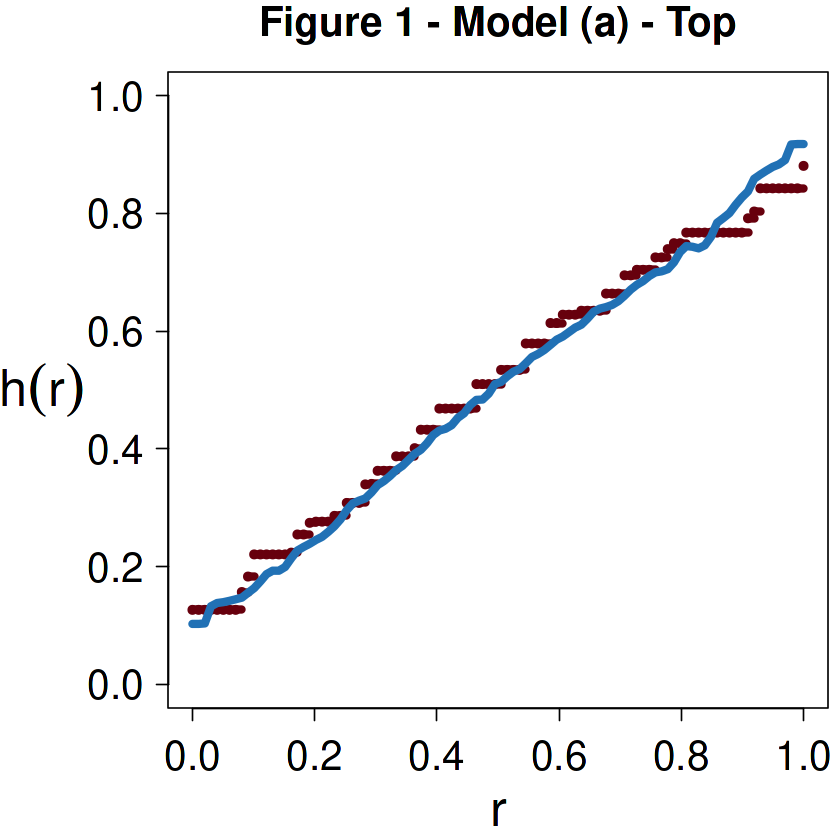

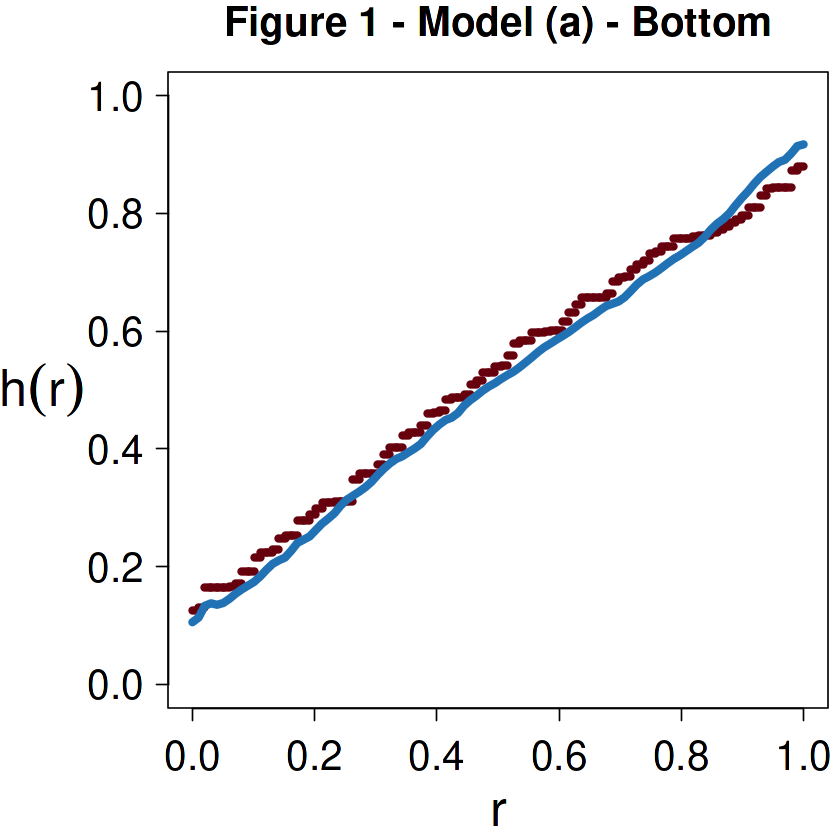

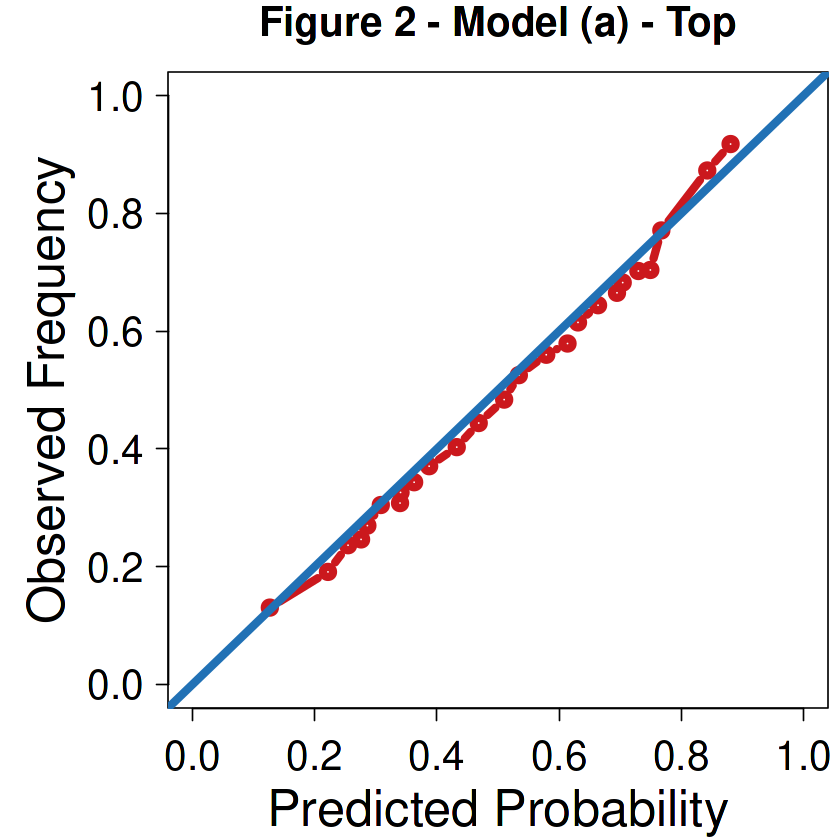

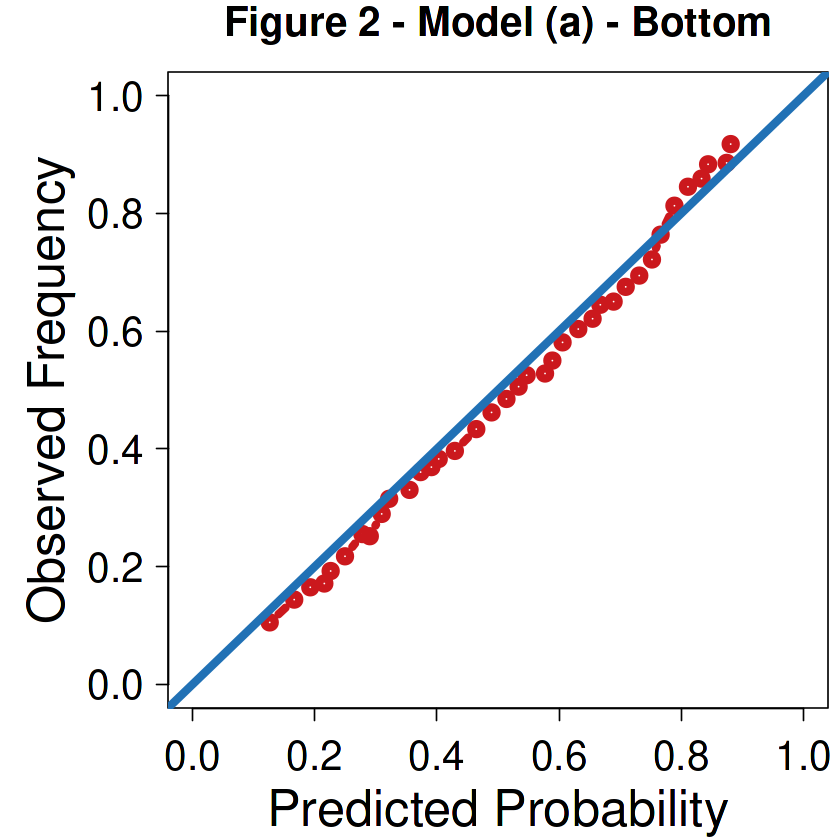

In [2]:
    #Genres (or Groups of Genres) under Comparison

    genre_A <- "Action"
    genre_B <- "Romance"   
    cat("Comparing:", genre_A, "vs", genre_B, paste0(" - Model (", letters[1], ")"),"\n")
    cat("----------------------------------------------------", "\n")
        
    #Intialization

    CIL0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIL1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
     
    #Specifying the Valid Users

    movies  <- movie_df[, .(movieId, title, genres)]
    ratings <- rating_df[, .(userId, movieId, rating, timestamp)]
    movies[, genres := as.character(genres)]
    movies[, is_A := grepl(paste0("(?i)\\b", genre_A, "\\b"), genres, perl = TRUE)]
    if (genre_B == paste0("Non-", genre_A)) {
      movies[, is_B := !is_A]
    } else {
      movies[, is_B := grepl(
        paste0("(?i)\\b", genre_B, "\\b"),
        genres,
        perl = TRUE
      )]
    }
    dt <- merge(ratings, movies[, .(movieId, title, genres, is_A, is_B)], by = "movieId", all.x = FALSE, all.y = FALSE)
    setorder(dt, userId, movieId, timestamp)
    dt_unique <- dt[, .SD[1], by = .(userId, movieId)]
    if (genre_B != paste0("Non-", genre_A)) {dt_cd <- dt_unique[(is_A & !is_B) | (is_B & !is_A)]} else {dt_cd <- dt_unique}
    setorder(dt_cd, userId, timestamp)
    user_counts <- dt_cd[, .N, by = userId]
    valid_users <- user_counts[N >= n, userId]
    N <- length(valid_users)
    cat("Number of valid users:", N, "\n")

    #Data Creation

    dt_valid <- dt_cd[userId %in% valid_users]
    dt_valid[, rank := seq_len(.N), by = userId]
    dt_firstT <- dt_valid[rank <= n]
    setorder(dt_firstT, userId, rank)
    user_ids <- unique(dt_firstT$userId)
    binary_vec <- as.integer(dt_firstT$is_A)
    binary_mat <- matrix(
      binary_vec,
      nrow = N,
      ncol = n,
      byrow = TRUE,
      dimnames = list(
        paste0("u", seq_len(N)),
        paste0("pos", seq_len(n))
      )
    )
    rating_mat <- matrix(
      as.numeric(dt_firstT$rating),
      nrow = N,
      ncol = n,
      byrow = TRUE
    )
    U <- binary_mat[1:N,]
    R0 <- matrix(nrow = N, ncol = n)
    R1 <- matrix(nrow = N, ncol = n)
    C1 <- rating_mat[1:N,]
    for(j in 1:N){
        R0[j,1] <- U[j,1]
        R1[j,1] <- (C1[j,1]*U[j,1])/C1[j,1]
        for(k in 2:n){
            R0[j,k] <- ((k-1)*R0[j,k-1] + U[j,k])/k                                       #Constant Intensity
            R1[j,k] <- ((sum(C1[j,1:(k-1)]))*R1[j,k-1] + C1[j,k]*U[j,k])/(sum(C1[j,1:k])) #Rating-based Intensity
        }
    }
    X0 <- sort(c(t(R0[,10:14])))
    X1 <- sort(c(t(R1[,10:14])))
    W0 <- as.data.frame(table(X0))
    W0$X <- as.numeric(as.character(W0$X))
    W1 <- as.data.frame(table(X1))
    W1$X <- as.numeric(as.character(W1$X))
    Y <- c(t(U[,11:15]))
    N0 <- rep(0,dim(W0)[1])
    N1 <- rep(0,dim(W1)[1])
    for(j in 1:dim(W0)[1]){
        N0[j] <- sum(Y[which(c(t(R0[,10:14])) == W0[j,1])])
    }
    for(j in 1:dim(W1)[1]){
        N1[j] <- sum(Y[which(c(t(R1[,10:14])) == W1[j,1])])
    }

    #Test Error for Constant Intensity

    c_gg_hat_slopes <- hat_h(W0, N0, grid_r)
    c_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R0[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Constant Intensity:", round(mean(abs(c_gg_hat_slopes - c_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Constant Intensity

    B <- 50
    pred_probs <- hat_h(W0, N0, as.vector(R0[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data0 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    c_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          c_ece <- c_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Constant Intensity:", round(c_ece,3), "\n")

    #Test Error for Rating-based Intensity

    r_gg_hat_slopes <- hat_h(W1, N1, grid_r) 
    r_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R1[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Rating-based Intensity:", round(mean(abs(r_gg_hat_slopes - r_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Rating-based Intensity

    B <- 50
    pred_probs <- hat_h(W1, N1, as.vector(R1[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data1 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    r_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          r_ece <- r_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Rating-based Intensity:", round(r_ece,3), "\n")

    #Figure 1 - Top

    cat("\n")
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- c_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = reds[4], las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- c_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 1 - Model (", letters[1], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 1 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- r_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = "white", las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- r_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)             
    title(main = paste0("Figure 1 - Model (", letters[1], ") - Bottom"), line = 1.5, cex.main = 2)  
                              
    #Figure 2 - Top
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data0$true_labels
    x  <- reliability_data0$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[1], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 2 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data1$true_labels
    x  <- reliability_data1$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[1], ") - Bottom"), line = 1.5, cex.main = 2)

Comparing: Comedy vs Romance  - Model (b) 


---------------------------------------------------- 


Number of valid users: 76094 


Test Error for Constant Intensity: 0.019 


ECE for Constant Intensity: 0.008 


Confidence Intervals for Constant Intensity:


  99r Lower Upper Estimate Oracle_Estimate
1  16 0.210 0.301    0.235           0.214
2  33 0.452 0.534    0.467           0.470
3  49 0.573 0.611    0.583           0.598
4  66 0.686 0.718    0.691           0.702
5  82 0.770 0.778    0.773           0.770


Test Error for Rating-based Intensity: 0.021 


ECE for Rating-based Intensity: 0.008 


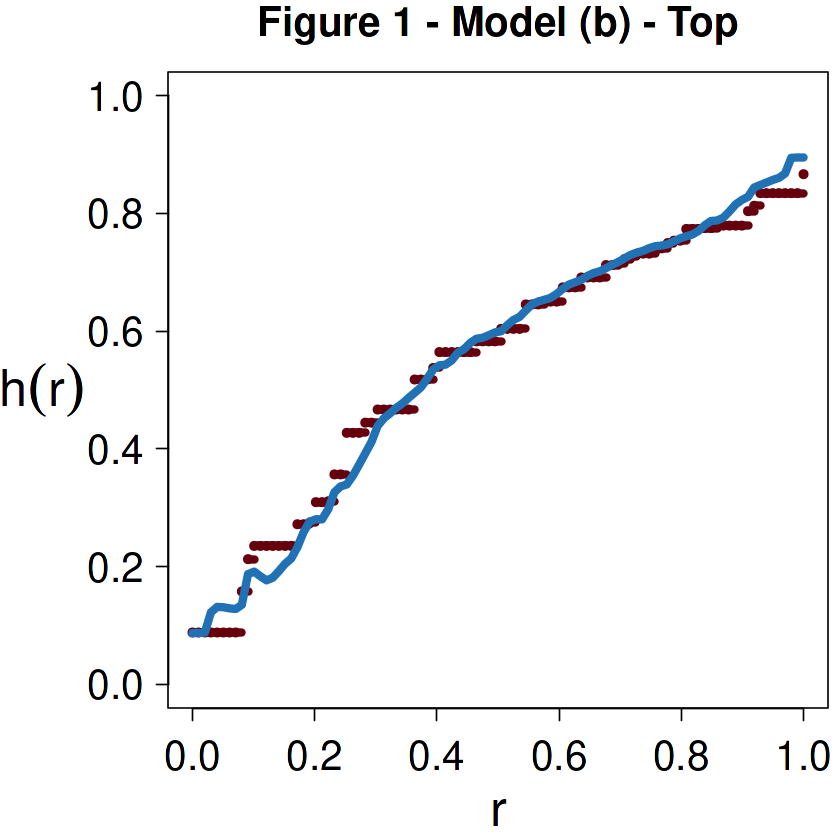

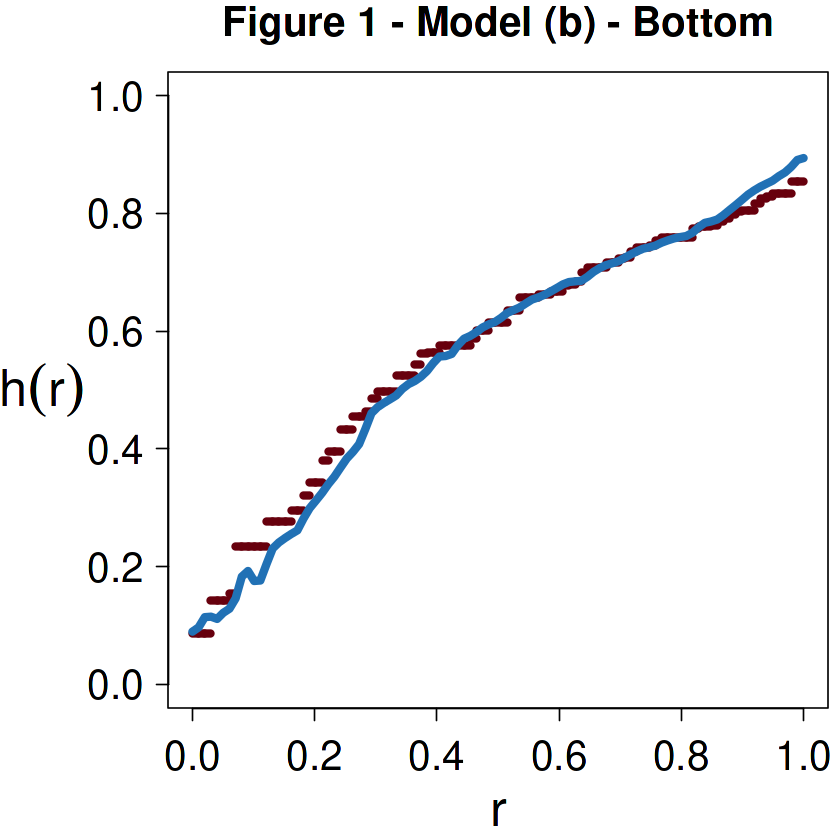

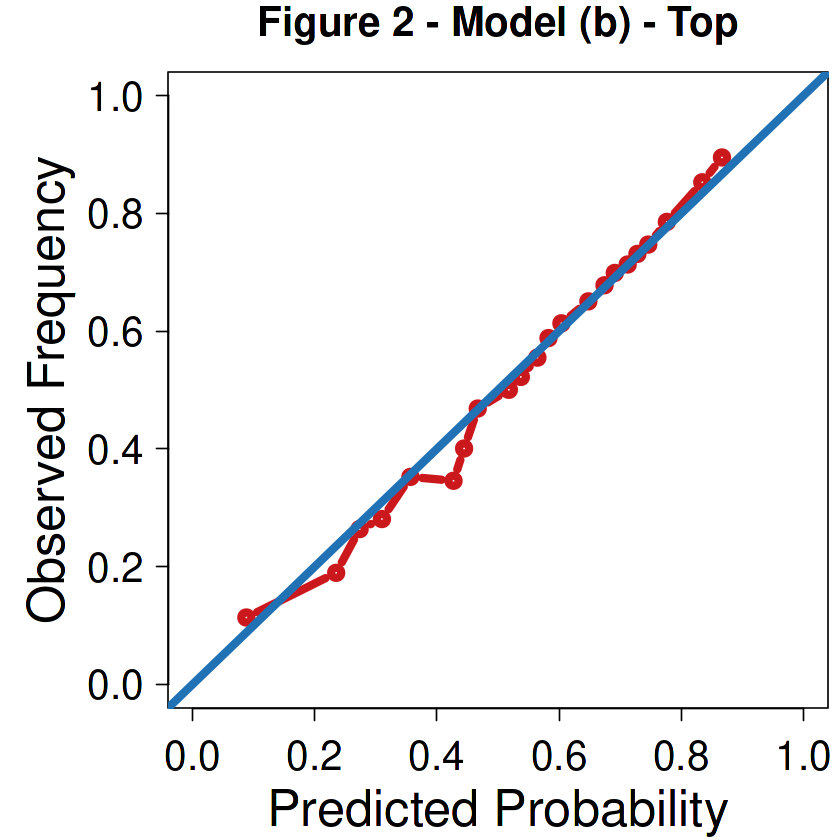

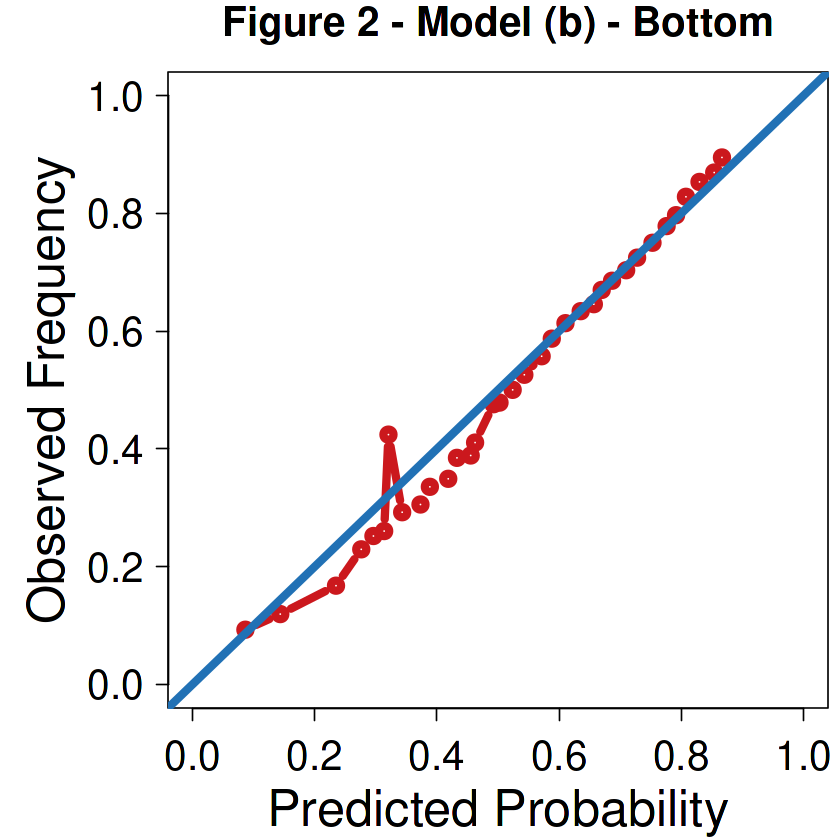

In [3]:
    #Genres (or Groups of Genres) under Comparison

    genre_A <- "Comedy"
    genre_B <- "Romance"       
    cat("Comparing:", genre_A, "vs", genre_B, paste0(" - Model (", letters[2], ")"),"\n")
    cat("----------------------------------------------------", "\n")
        
    #Intialization

    CIL0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIL1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
     
    #Specifying the Valid Users

    movies  <- movie_df[, .(movieId, title, genres)]
    ratings <- rating_df[, .(userId, movieId, rating, timestamp)]
    movies[, genres := as.character(genres)]
    movies[, is_A := grepl(paste0("(?i)\\b", genre_A, "\\b"), genres, perl = TRUE)]
    if (genre_B == paste0("Non-", genre_A)) {
      movies[, is_B := !is_A]
    } else {
      movies[, is_B := grepl(
        paste0("(?i)\\b", genre_B, "\\b"),
        genres,
        perl = TRUE
      )]
    }
    dt <- merge(ratings, movies[, .(movieId, title, genres, is_A, is_B)], by = "movieId", all.x = FALSE, all.y = FALSE)
    setorder(dt, userId, movieId, timestamp)
    dt_unique <- dt[, .SD[1], by = .(userId, movieId)]
    if (genre_B != paste0("Non-", genre_A)) {dt_cd <- dt_unique[(is_A & !is_B) | (is_B & !is_A)]} else {dt_cd <- dt_unique}
    setorder(dt_cd, userId, timestamp)
    user_counts <- dt_cd[, .N, by = userId]
    valid_users <- user_counts[N >= n, userId]
    N <- length(valid_users)
    cat("Number of valid users:", N, "\n")

    #Data Creation

    dt_valid <- dt_cd[userId %in% valid_users]
    dt_valid[, rank := seq_len(.N), by = userId]
    dt_firstT <- dt_valid[rank <= n]
    setorder(dt_firstT, userId, rank)
    user_ids <- unique(dt_firstT$userId)
    binary_vec <- as.integer(dt_firstT$is_A)
    binary_mat <- matrix(
      binary_vec,
      nrow = N,
      ncol = n,
      byrow = TRUE,
      dimnames = list(
        paste0("u", seq_len(N)),
        paste0("pos", seq_len(n))
      )
    )
    rating_mat <- matrix(
      as.numeric(dt_firstT$rating),
      nrow = N,
      ncol = n,
      byrow = TRUE
    )
    U <- binary_mat[1:N,]
    R0 <- matrix(nrow = N, ncol = n)
    R1 <- matrix(nrow = N, ncol = n)
    C1 <- rating_mat[1:N,]
    for(j in 1:N){
        R0[j,1] <- U[j,1]
        R1[j,1] <- (C1[j,1]*U[j,1])/C1[j,1]
        for(k in 2:n){
            R0[j,k] <- ((k-1)*R0[j,k-1] + U[j,k])/k                                       #Constant Intensity
            R1[j,k] <- ((sum(C1[j,1:(k-1)]))*R1[j,k-1] + C1[j,k]*U[j,k])/(sum(C1[j,1:k])) #Rating-based Intensity
        }
    }
    X0 <- sort(c(t(R0[,10:14])))
    X1 <- sort(c(t(R1[,10:14])))
    W0 <- as.data.frame(table(X0))
    W0$X <- as.numeric(as.character(W0$X))
    W1 <- as.data.frame(table(X1))
    W1$X <- as.numeric(as.character(W1$X))
    Y <- c(t(U[,11:15]))
    N0 <- rep(0,dim(W0)[1])
    N1 <- rep(0,dim(W1)[1])
    for(j in 1:dim(W0)[1]){
        N0[j] <- sum(Y[which(c(t(R0[,10:14])) == W0[j,1])])
    }
    for(j in 1:dim(W1)[1]){
        N1[j] <- sum(Y[which(c(t(R1[,10:14])) == W1[j,1])])
    }

    #Test Error for Constant Intensity

    c_gg_hat_slopes <- hat_h(W0, N0, grid_r)
    c_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R0[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Constant Intensity:", round(mean(abs(c_gg_hat_slopes - c_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Constant Intensity

    B <- 50
    pred_probs <- hat_h(W0, N0, as.vector(R0[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data0 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    c_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          c_ece <- c_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Constant Intensity:", round(c_ece,3), "\n")

    #Confidence Intervals for Constant Intensity

    p_hat <- hat_h(W0, N0, W0$X)
    ll1 <- loglik_from_slopes(p_hat, W0, N0)
    for (pi in seq_along(pot_grid)) {
    r0 <- pot_grid[pi]
    theta_hat <- hat_h(W0, N0, r0)[1]
    compute_LRT <- function(theta) {
    p_hat0 <- hat_h0(theta, W0, N0, r0, W0$X)
    ll0 <- loglik_from_slopes(p_hat0, W0, N0)
    2 * (ll1 - ll0)
    }
    f_root <- function(th) compute_LRT(th) - crit
    lower <- 0
    upper <- 1
    if (f_root(lower) * f_root(theta_hat) <= 0) {
     CIL0[pi,1] <- compute_root(f_root, lower, theta_hat)
    } else {
     CIL0[pi,1] <- NA
    }
    if (f_root(theta_hat) * f_root(upper) <= 0) {
     CIR0[pi,1] <- compute_root(f_root, theta_hat, upper)
    } else {
     CIR0[pi,1] <- NA
    }
    }  
    ci_table0 <- data.frame( `99r` = 99*pot_grid, Lower  = CIL0, Upper  = CIR0, Estimate = hat_h(W0, N0, pot_grid), 
                            Oracle_Estimate = sapply(pot_grid, kernel_est, R = as.vector(R0[,15:19]), U = as.vector(U[,16:20]), h = bandwidth), check.names = FALSE)
    cat("\n")
    cat("Confidence Intervals for Constant Intensity:\n")
    print(round(ci_table0,3))

    #Test Error for Rating-based Intensity

    r_gg_hat_slopes <- hat_h(W1, N1, grid_r) 
    r_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R1[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Rating-based Intensity:", round(mean(abs(r_gg_hat_slopes - r_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Rating-based Intensity

    B <- 50
    pred_probs <- hat_h(W1, N1, as.vector(R1[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data1 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    r_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          r_ece <- r_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Rating-based Intensity:", round(r_ece,3), "\n")

    #Figure 1 - Top

    cat("\n")
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- c_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = reds[4], las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- c_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 1 - Model (", letters[2], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 1 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- r_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = "white", las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- r_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)             
    title(main = paste0("Figure 1 - Model (", letters[2], ") - Bottom"), line = 1.5, cex.main = 2)  
                              
    #Figure 2 - Top
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data0$true_labels
    x  <- reliability_data0$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[2], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 2 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data1$true_labels
    x  <- reliability_data1$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[2], ") - Bottom"), line = 1.5, cex.main = 2)

Comparing: Action Adventure Thriller vs Romance Drama  - Model (c) 


---------------------------------------------------- 


Number of valid users: 112038 


Test Error for Constant Intensity: 0.026 


ECE for Constant Intensity: 0.014 


Test Error for Rating-based Intensity: 0.026 


ECE for Rating-based Intensity: 0.015 


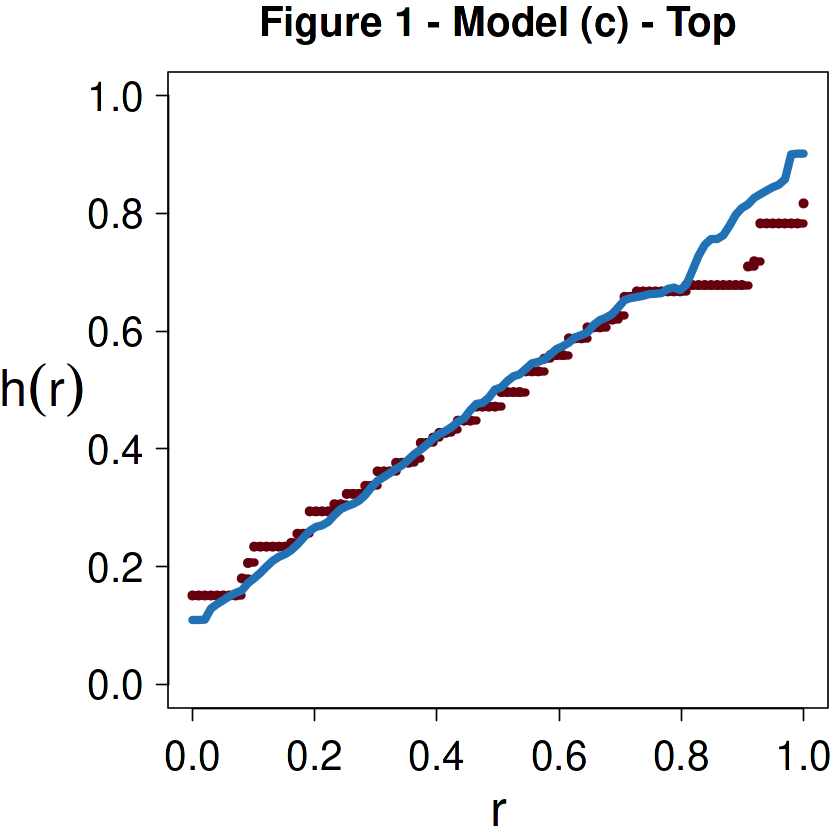

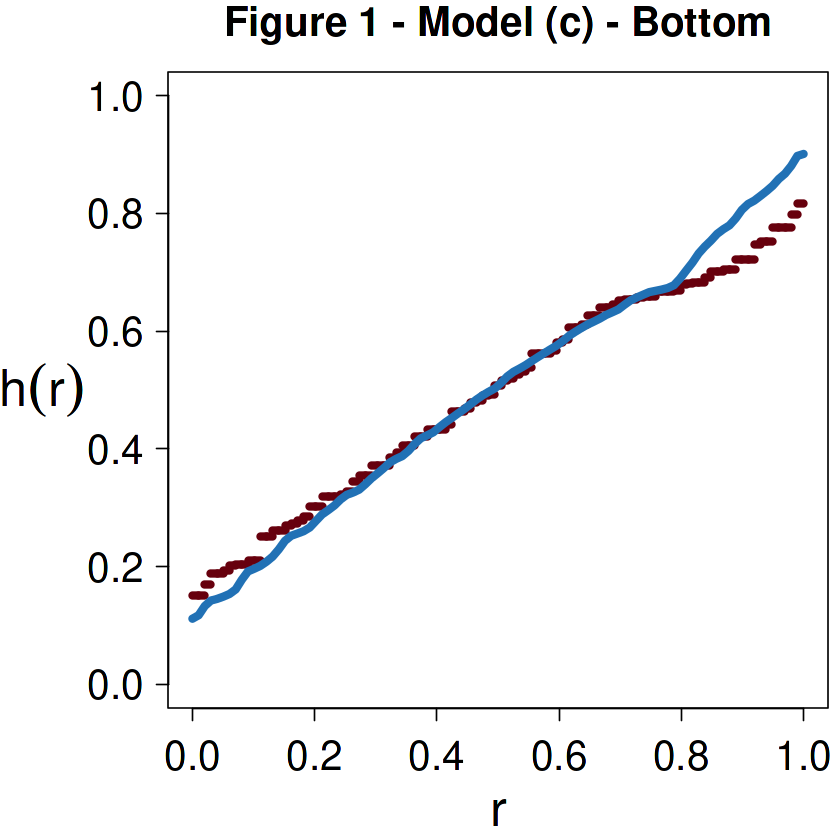

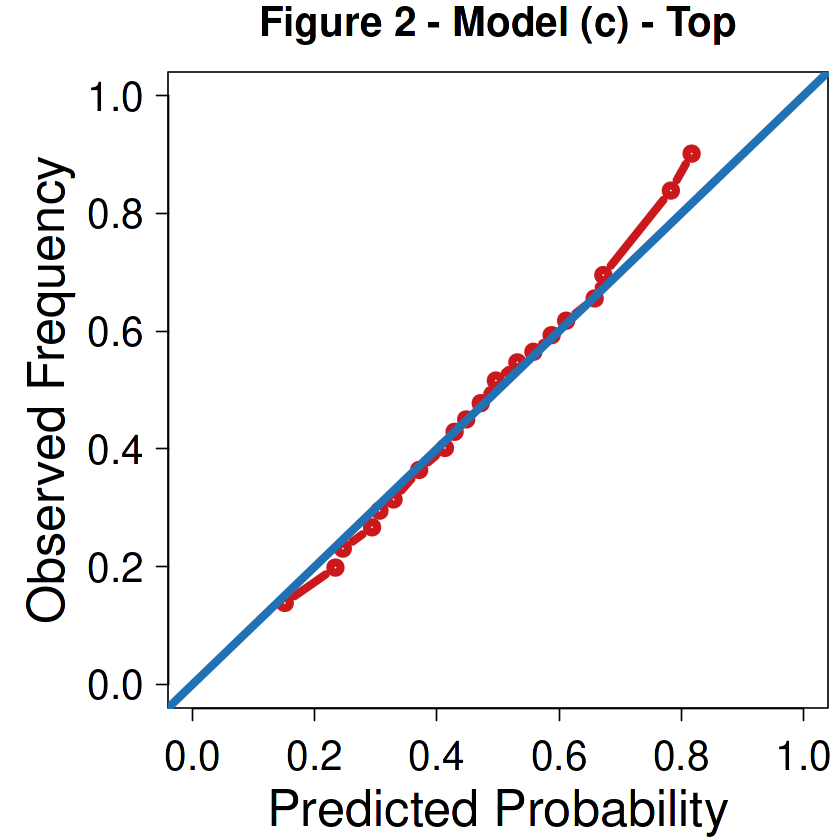

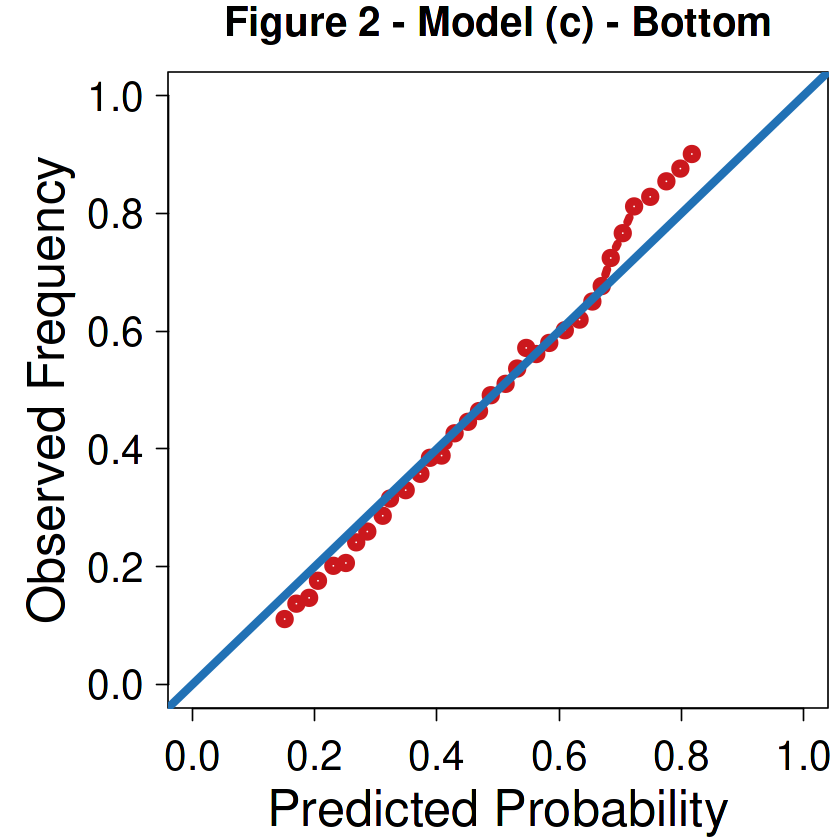

In [4]:
    #Genres (or Groups of Genres) under Comparison

    genre_A <- c("Action", "Adventure", "Thriller")
    genre_B <- c("Romance", "Drama")  
    cat("Comparing:", genre_A, "vs", genre_B, paste0(" - Model (", letters[3], ")"),"\n")
    cat("----------------------------------------------------", "\n")
        
    #Intialization

    CIL0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIL1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
     
    #Specifying the Valid Users

    movies  <- movie_df[, .(movieId, title, genres)]
    ratings <- rating_df[, .(userId, movieId, rating, timestamp)]
    movies[, genres := as.character(genres)]
    movies[, genre_list := strsplit(genres, "\\|")]
    movies[, is_A := sapply(genre_list, function(g) any(g %in% genre_A))]
    if (length(genre_B) == 1 && grepl("^Non-", genre_B)) {
      movies[, is_B := !is_A]
    } else {
      movies[, is_B := sapply(genre_list, function(g) any(g %in% genre_B))]
    }
    dt <- merge(
      ratings,
      movies[, .(movieId, title, genres, is_A, is_B)],
      by = "movieId",
      all.x = FALSE,
      all.y = FALSE
    )
    setorder(dt, userId, movieId, timestamp)
    dt_unique <- dt[, .SD[1], by = .(userId, movieId)]
    dt_cd <- dt_unique[(is_A & !is_B) | (is_B & !is_A)]
    setorder(dt_cd, userId, timestamp)
    user_counts <- dt_cd[, .N, by = userId]
    valid_users <- user_counts[N >= n, userId]
    N <- length(valid_users)
    cat("Number of valid users:", N, "\n")

    #Data Creation

    dt_valid <- dt_cd[userId %in% valid_users]
    dt_valid[, rank := seq_len(.N), by = userId]
    dt_firstT <- dt_valid[rank <= n]
    setorder(dt_firstT, userId, rank)
    user_ids <- unique(dt_firstT$userId)
    binary_vec <- as.integer(dt_firstT$is_A)
    binary_mat <- matrix(
      binary_vec,
      nrow = N,
      ncol = n,
      byrow = TRUE,
      dimnames = list(
        paste0("u", seq_len(N)),
        paste0("pos", seq_len(n))
      )
    )
    rating_mat <- matrix(
      as.numeric(dt_firstT$rating),
      nrow = N,
      ncol = n,
      byrow = TRUE
    )
    U <- binary_mat[1:N,]
    R0 <- matrix(nrow = N, ncol = n)
    R1 <- matrix(nrow = N, ncol = n)
    C1 <- rating_mat[1:N,]
    for(j in 1:N){
        R0[j,1] <- U[j,1]
        R1[j,1] <- (C1[j,1]*U[j,1])/C1[j,1]
        for(k in 2:n){
            R0[j,k] <- ((k-1)*R0[j,k-1] + U[j,k])/k                                       #Constant Intensity
            R1[j,k] <- ((sum(C1[j,1:(k-1)]))*R1[j,k-1] + C1[j,k]*U[j,k])/(sum(C1[j,1:k])) #Rating-based Intensity
        }
    }
    X0 <- sort(c(t(R0[,10:14])))
    X1 <- sort(c(t(R1[,10:14])))
    W0 <- as.data.frame(table(X0))
    W0$X <- as.numeric(as.character(W0$X))
    W1 <- as.data.frame(table(X1))
    W1$X <- as.numeric(as.character(W1$X))
    Y <- c(t(U[,11:15]))
    N0 <- rep(0,dim(W0)[1])
    N1 <- rep(0,dim(W1)[1])
    for(j in 1:dim(W0)[1]){
        N0[j] <- sum(Y[which(c(t(R0[,10:14])) == W0[j,1])])
    }
    for(j in 1:dim(W1)[1]){
        N1[j] <- sum(Y[which(c(t(R1[,10:14])) == W1[j,1])])
    }

    #Test Error for Constant Intensity

    c_gg_hat_slopes <- hat_h(W0, N0, grid_r)
    c_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R0[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Constant Intensity:", round(mean(abs(c_gg_hat_slopes - c_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Constant Intensity

    B <- 50
    pred_probs <- hat_h(W0, N0, as.vector(R0[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data0 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    c_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          c_ece <- c_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Constant Intensity:", round(c_ece,3), "\n")

    #Test Error for Rating-based Intensity

    r_gg_hat_slopes <- hat_h(W1, N1, grid_r) 
    r_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R1[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Rating-based Intensity:", round(mean(abs(r_gg_hat_slopes - r_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Rating-based Intensity

    B <- 50
    pred_probs <- hat_h(W1, N1, as.vector(R1[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data1 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    r_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          r_ece <- r_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Rating-based Intensity:", round(r_ece,3), "\n")

    #Figure 1 - Top

    cat("\n")                          
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- c_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = reds[4], las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- c_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 1 - Model (", letters[3], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 1 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- r_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = "white", las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- r_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)             
    title(main = paste0("Figure 1 - Model (", letters[3], ") - Bottom"), line = 1.5, cex.main = 2)  
                              
    #Figure 2 - Top
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data0$true_labels
    x  <- reliability_data0$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[3], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 2 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data1$true_labels
    x  <- reliability_data1$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[3], ") - Bottom"), line = 1.5, cex.main = 2)

Comparing: Action Adventure Thriller vs Comedy  - Model (d) 


---------------------------------------------------- 


Number of valid users: 112340 


Test Error for Constant Intensity: 0.031 


ECE for Constant Intensity: 0.019 


Test Error for Rating-based Intensity: 0.033 


ECE for Rating-based Intensity: 0.017 


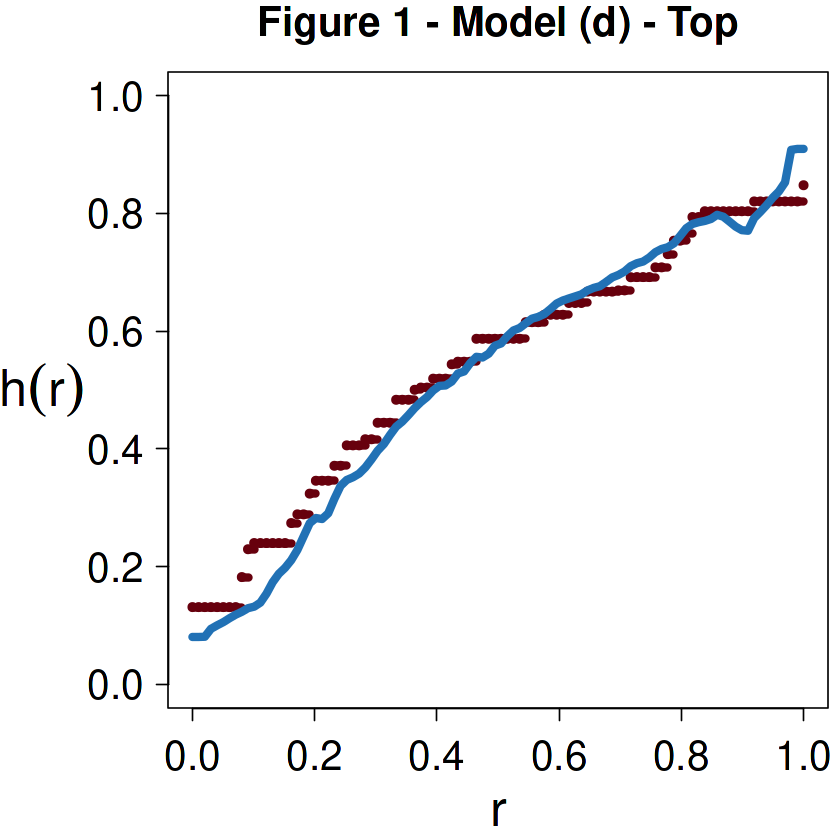

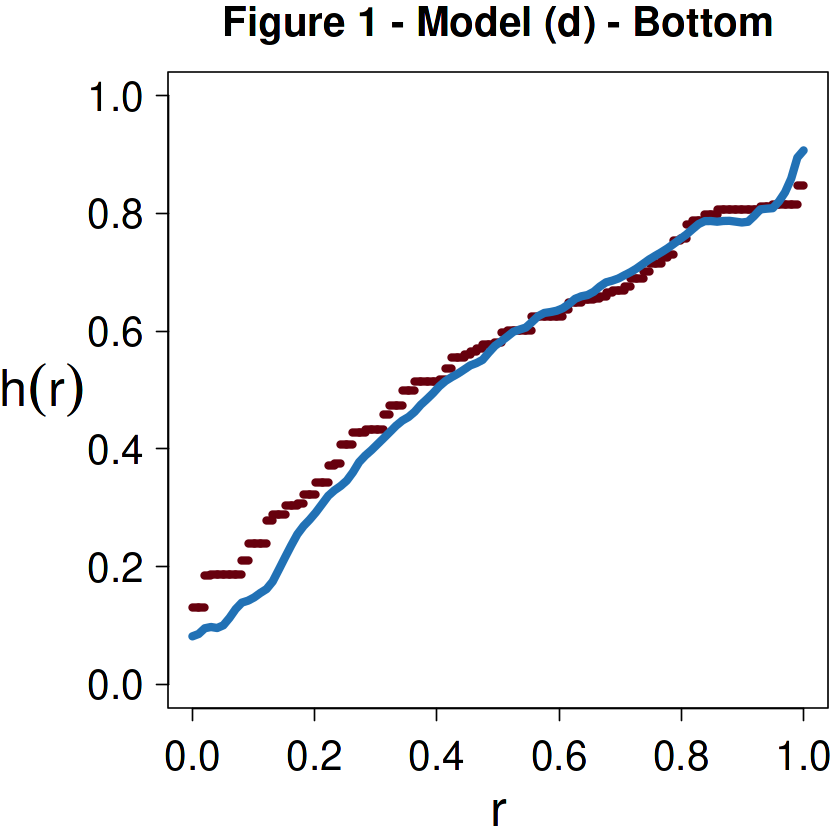

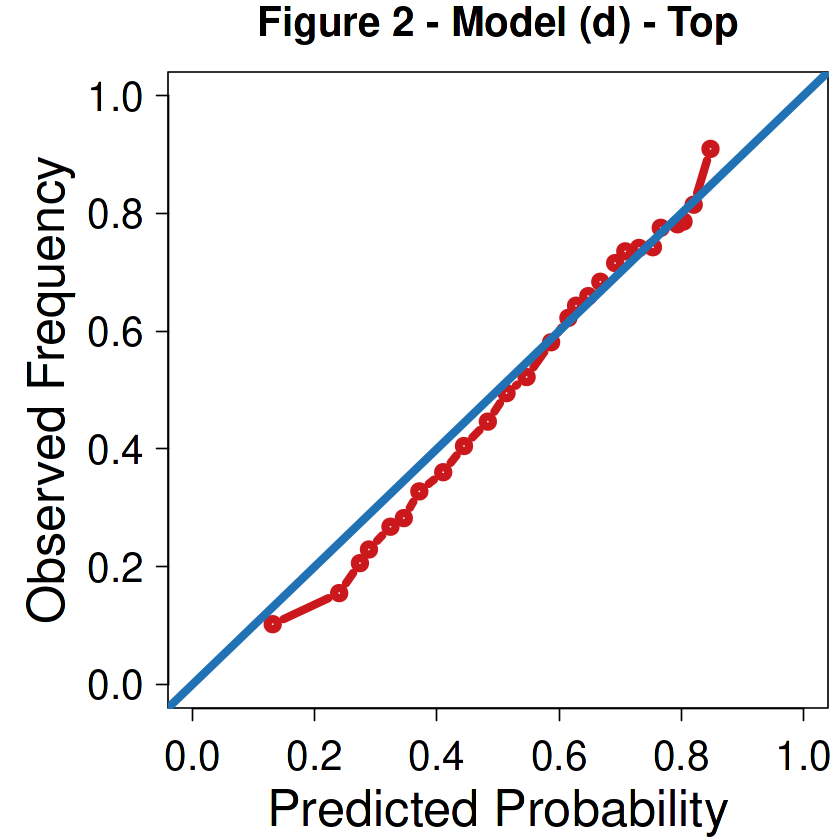

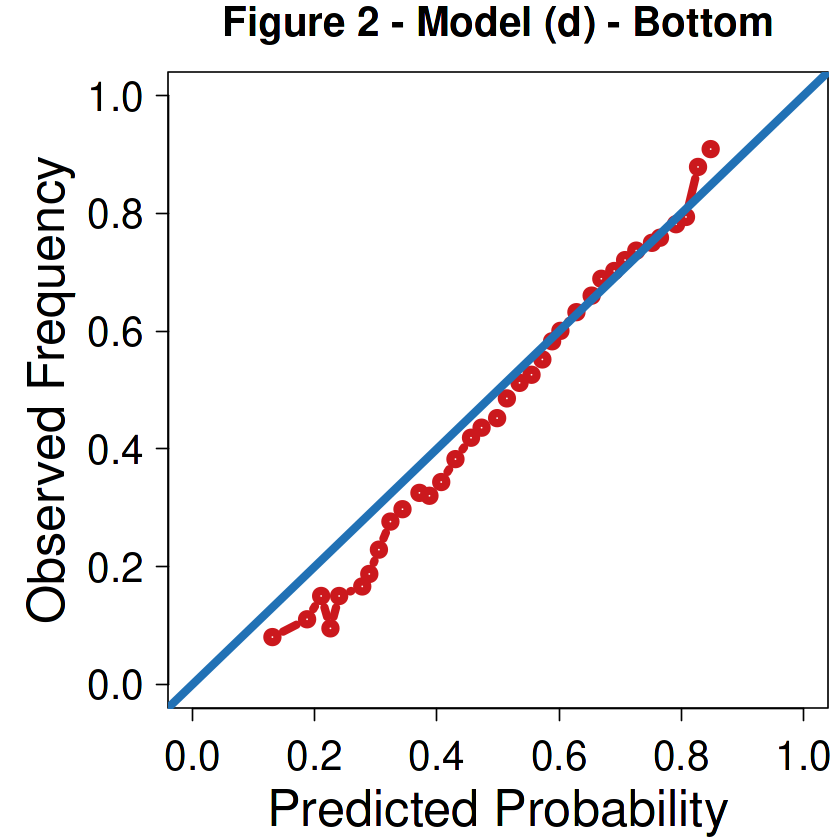

In [5]:
    #Genres (or Groups of Genres) under Comparison

    genre_A <- c("Action", "Adventure", "Thriller")
    genre_B <- c("Comedy")
    cat("Comparing:", genre_A, "vs", genre_B, paste0(" - Model (", letters[4], ")"),"\n")
    cat("----------------------------------------------------", "\n")
        
    #Intialization

    CIL0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR0 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIL1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
    CIR1 <- matrix(NA, nrow = length(pot_grid), ncol = 1)
     
    #Specifying the Valid Users

    movies  <- movie_df[, .(movieId, title, genres)]
    ratings <- rating_df[, .(userId, movieId, rating, timestamp)]
    movies[, genres := as.character(genres)]
    movies[, genre_list := strsplit(genres, "\\|")]
    movies[, is_A := sapply(genre_list, function(g) any(g %in% genre_A))]
    if (length(genre_B) == 1 && grepl("^Non-", genre_B)) {
      movies[, is_B := !is_A]
    } else {
      movies[, is_B := sapply(genre_list, function(g) any(g %in% genre_B))]
    }
    dt <- merge(
      ratings,
      movies[, .(movieId, title, genres, is_A, is_B)],
      by = "movieId",
      all.x = FALSE,
      all.y = FALSE
    )
    setorder(dt, userId, movieId, timestamp)
    dt_unique <- dt[, .SD[1], by = .(userId, movieId)]
    dt_cd <- dt_unique[(is_A & !is_B) | (is_B & !is_A)]
    setorder(dt_cd, userId, timestamp)
    user_counts <- dt_cd[, .N, by = userId]
    valid_users <- user_counts[N >= n, userId]
    N <- length(valid_users)
    cat("Number of valid users:", N, "\n")

    #Data Creation

    dt_valid <- dt_cd[userId %in% valid_users]
    dt_valid[, rank := seq_len(.N), by = userId]
    dt_firstT <- dt_valid[rank <= n]
    setorder(dt_firstT, userId, rank)
    user_ids <- unique(dt_firstT$userId)
    binary_vec <- as.integer(dt_firstT$is_A)
    binary_mat <- matrix(
      binary_vec,
      nrow = N,
      ncol = n,
      byrow = TRUE,
      dimnames = list(
        paste0("u", seq_len(N)),
        paste0("pos", seq_len(n))
      )
    )
    rating_mat <- matrix(
      as.numeric(dt_firstT$rating),
      nrow = N,
      ncol = n,
      byrow = TRUE
    )
    U <- binary_mat[1:N,]
    R0 <- matrix(nrow = N, ncol = n)
    R1 <- matrix(nrow = N, ncol = n)
    C1 <- rating_mat[1:N,]
    for(j in 1:N){
        R0[j,1] <- U[j,1]
        R1[j,1] <- (C1[j,1]*U[j,1])/C1[j,1]
        for(k in 2:n){
            R0[j,k] <- ((k-1)*R0[j,k-1] + U[j,k])/k                                       #Constant Intensity
            R1[j,k] <- ((sum(C1[j,1:(k-1)]))*R1[j,k-1] + C1[j,k]*U[j,k])/(sum(C1[j,1:k])) #Rating-based Intensity
        }
    }
    X0 <- sort(c(t(R0[,10:14])))
    X1 <- sort(c(t(R1[,10:14])))
    W0 <- as.data.frame(table(X0))
    W0$X <- as.numeric(as.character(W0$X))
    W1 <- as.data.frame(table(X1))
    W1$X <- as.numeric(as.character(W1$X))
    Y <- c(t(U[,11:15]))
    N0 <- rep(0,dim(W0)[1])
    N1 <- rep(0,dim(W1)[1])
    for(j in 1:dim(W0)[1]){
        N0[j] <- sum(Y[which(c(t(R0[,10:14])) == W0[j,1])])
    }
    for(j in 1:dim(W1)[1]){
        N1[j] <- sum(Y[which(c(t(R1[,10:14])) == W1[j,1])])
    }

    #Test Error for Constant Intensity

    c_gg_hat_slopes <- hat_h(W0, N0, grid_r)
    c_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R0[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Constant Intensity:", round(mean(abs(c_gg_hat_slopes - c_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Constant Intensity

    B <- 50
    pred_probs <- hat_h(W0, N0, as.vector(R0[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data0 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    c_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          c_ece <- c_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Constant Intensity:", round(c_ece,3), "\n")

    #Test Error for Rating-based Intensity

    r_gg_hat_slopes <- hat_h(W1, N1, grid_r) 
    r_gg_true_slopes_te <- sapply(grid_r, kernel_est, R = as.vector(R1[,15:19]), U = as.vector(U[,16:20]), h = bandwidth)
    cat("\n")
    cat("Test Error for Rating-based Intensity:", round(mean(abs(r_gg_hat_slopes - r_gg_true_slopes_te)),3), "\n") 

    #Empirical Calibration Error for Rating-based Intensity

    B <- 50
    pred_probs <- hat_h(W1, N1, as.vector(R1[,15:19]))
    true_labels <- as.vector(U[,16:20])              
    bin_ids <- cut(pred_probs, breaks = seq(0, 1, length.out = B + 1), include.lowest = TRUE, right = FALSE)
    reliability_data1 <- aggregate(cbind(pred_probs, true_labels), by = list(bin = bin_ids), FUN = mean)
    r_ece <- 0
    for (b in levels(bin_ids)) {
        idx <- which(bin_ids == b)
        if (length(idx) > 0) {
          acc_b  <- mean(true_labels[idx])       
          conf_b <- mean(pred_probs[idx])      
          r_ece <- r_ece + (length(idx)/length(pred_probs)) * abs(acc_b - conf_b)
        }
      }
    cat("ECE for Rating-based Intensity:", round(r_ece,3), "\n")

    #Figure 1 - Top

    cat("\n")                          
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- c_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = reds[4], las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- c_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 1 - Model (", letters[4], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 1 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- r_gg_hat_slopes
    x  <- grid_r
    plot(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = "white", las = 1, xaxt = "n")
    for (i in 1:(length(x)-1)) {segments(x[i], m[i], x[i+1], m[i], col = reds[4], lwd = 5)}
    m  <- r_gg_true_slopes_te
    lines(x, m, xlab = "", ylab = "", ylim = c(0, 1), pch = 16, col = blues[3], las = 1, xaxt = "n", lwd = 5)
    axis(1, mgp = c(3, 1.7, 0))
    mtext(expression(h(r)), side = 2, line = 3.4, las = 1, cex = 2.5)
    mtext(expression(r), side = 1, line = 4, las = 1, cex = 2.5)             
    title(main = paste0("Figure 1 - Model (", letters[4], ") - Bottom"), line = 1.5, cex.main = 2)  
                              
    #Figure 2 - Top
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data0$true_labels
    x  <- reliability_data0$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[4], ") - Top"), line = 1.5, cex.main = 2)
                              
    #Figure 2 - Bottom
        
    par(mar = c(5.5, 7, 3, 0.5), cex.axis = 2, cex.lab  = 2.5, bty = "o")
    m  <- reliability_data1$true_labels
    x  <- reliability_data1$pred_probs
    plot(x, m, xlab = "", ylab = "", xlim = c(0, 1), ylim = c(0, 1), type = "b", lwd = 5, col = reds[3], las = 1, xaxt = "n")
    abline(0,1, lwd = 5, col=blues[3])  
    axis(1, mgp = c(3, 1.7, 0))
    mtext("Observed Frequency", side = 2, line = 4.25, las = 3, cex = 2.5)
    mtext("Predicted Probability", side = 1, line = 4, las = 1, cex = 2.5)
    title(main = paste0("Figure 2 - Model (", letters[4], ") - Bottom"), line = 1.5, cex.main = 2)

 